In [1]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from typing import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver

c:\Users\Ansh\OneDrive\Desktop\LANGRAPH\meraenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os
load_dotenv()
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv('GROQ_API_KEY'),
    temperature=0
)

In [3]:
llm.invoke('hi').content

'How can I assist you today?'

In [4]:
class Substate(TypedDict):
    input_txt:str
    translated_txt: str

In [5]:
def translate(state:Substate):
    prompt = f"Translate the following text to Hindi: {state['input_txt']}"
    translated_txt = llm.invoke(prompt).content
    return {'translated_txt': translated_txt}


In [6]:
Subgraph = StateGraph(Substate)

Subgraph.add_node('translate', translate)

Subgraph.add_edge(START, 'translate')
Subgraph.add_edge('translate', END)

subflow = Subgraph.compile()

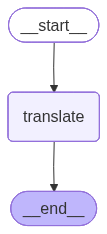

In [7]:
Subgraph.compile()

In [8]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str
    

In [9]:
def generate(state:ParentState):
    prompt = f"Answer the following question in English: {state['question']}"
    answer_eng = llm.invoke(prompt).content

    return {'answer_eng': answer_eng}

In [10]:
def translate_answer(state:ParentState):
    result = subflow.invoke({'input_txt':state['answer_eng']})
    
    # invoke functon returns whole state of the graph
    # result will return whole state of subgraph and from that whole state we want translated_txt

    return {'answer_hin':result['translated_txt']}

In [11]:
Parentgraph = StateGraph(ParentState)
Parentgraph.add_node('generate',generate)
Parentgraph.add_node('translate_answer',translate_answer)

Parentgraph.add_edge(START,'generate')
Parentgraph.add_edge('generate','translate_answer')
Parentgraph.add_edge('translate_answer',END)

workflow = Parentgraph.compile()

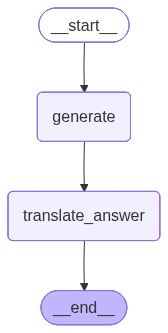

In [12]:
Parentgraph.compile()

In [14]:
workflow.invoke({'question':'what is boston'})

{'question': 'what is boston',
 'answer_eng': 'Boston is the capital and largest city of the state of Massachusetts, in the United States. It is located in the northeastern part of the country, along the Atlantic coast. Boston is a major cultural, economic, and educational hub, known for its rich history, vibrant neighborhoods, and world-class institutions.\n\nBoston was founded in 1630 by English Puritans, who established the Massachusetts Bay Colony. The city played a significant role in American history, particularly during the American Revolution, when it was a major hub for patriots and the site of many key events, including the Boston Massacre, the Boston Tea Party, and the Battle of Bunker Hill.\n\nToday, Boston is a thriving city with a diverse population of over 675,000 people. It is home to many world-renowned institutions, including:\n\n1. Harvard University, one of the oldest and most prestigious universities in the world.\n2. The Massachusetts Institute of Technology (MIT)